<a href="https://colab.research.google.com/github/harshinisathya09-star/projects-/blob/main/assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

In [2]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [3]:
print("Dataset Information")
print(df.info())
print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64','float64']).columns)
print("\nCategorical Columns:")
print(df.select_dtypes(include=['object']).columns)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [4]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [6]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print("Number of Outliers:", len(outliers))

Number of Outliers: 66


In [7]:
df = df[(df['Age'] >= lower) & (df['Age'] <= upper)]

In [8]:
print("Duplicates Before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [9]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   825.000000  825.000000  825.000000  825.000000  825.000000   
mean    447.369697    0.380606    2.341818   28.515152    0.507879   
std     257.088865    0.485830    0.824096   10.177256    1.090670   
min       1.000000    0.000000    1.000000    3.000000    0.000000   
25%     226.000000    0.000000    2.000000   22.000000    0.000000   
50%     445.000000    0.000000    3.000000   28.000000    0.000000   
75%     671.000000    1.000000    3.000000   34.000000    1.000000   
max     891.000000    1.000000    3.000000   54.000000    8.000000   

            Parch        Fare  
count  825.000000  825.000000  
mean     0.357576   31.483615  
std      0.798599   49.956429  
min      0.000000    0.000000  
25%      0.000000    7.895800  
50%      0.000000   13.416700  
75%      0.000000   30.070800  
max      6.000000  512.329200  


In [10]:
print(df['Survived'].value_counts())

Survived
0    511
1    314
Name: count, dtype: int64


In [11]:
print(df['Sex'].value_counts())

Sex
male      531
female    294
Name: count, dtype: int64


In [12]:
print(df['Pclass'].value_counts())

Pclass
3    469
1    187
2    169
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

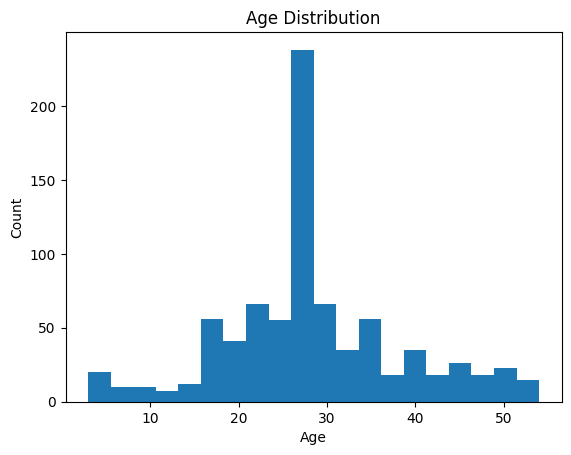

In [14]:
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

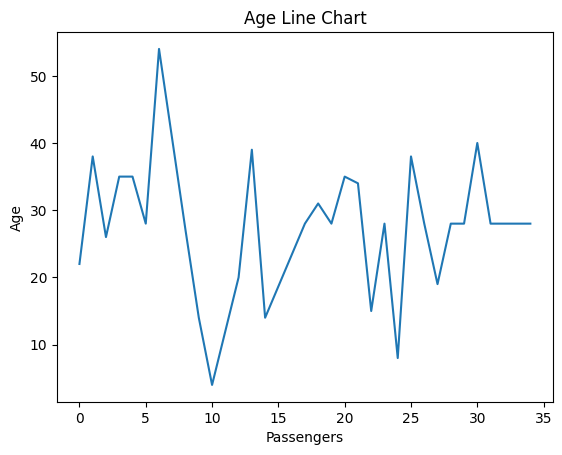

In [15]:
df['Age'].head(30).plot(kind='line')
plt.title("Age Line Chart")
plt.xlabel("Passengers")
plt.ylabel("Age")
plt.show()

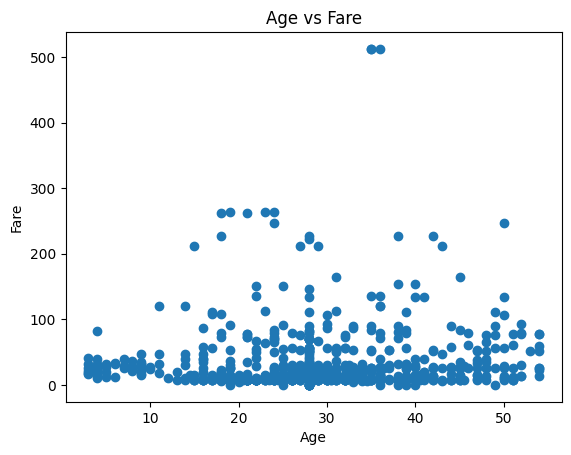

In [16]:
plt.scatter(df['Age'], df['Fare'])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

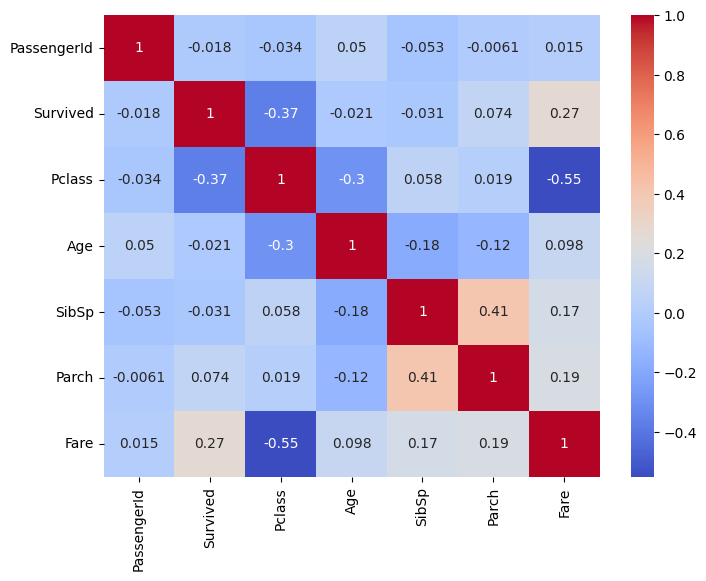

In [17]:
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

df['Embarked'] = encoder.fit_transform(df['Embarked'])

df['Cabin'] = encoder.fit_transform(df['Cabin'])

df['Name'] = encoder.fit_transform(df['Name'])

df['Ticket'] = encoder.fit_transform(df['Ticket'])

In [19]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [24]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
log_acc = accuracy_score(y_test, log_pred)
tree_acc = accuracy_score(y_test, tree_pred)
print("Logistic Regression Accuracy:", log_acc)
print("Decision Tree Accuracy:", tree_acc)

Logistic Regression Accuracy: 0.806060606060606
Decision Tree Accuracy: 0.7757575757575758


In [26]:
from sklearn.metrics import classification_report
print("Logistic Regression Report")
print(classification_report(y_test, log_pred))
print("Decision Tree Report")
print(classification_report(y_test, tree_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        99
           1       0.74      0.79      0.76        66

    accuracy                           0.81       165
   macro avg       0.80      0.80      0.80       165
weighted avg       0.81      0.81      0.81       165

Decision Tree Report
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        99
           1       0.70      0.77      0.73        66

    accuracy                           0.78       165
   macro avg       0.77      0.78      0.77       165
weighted avg       0.78      0.78      0.78       165



In [27]:
from sklearn.metrics import classification_report
print("Logistic Regression Report")
print(classification_report(y_test, log_pred))
print("Decision Tree Report")
print(classification_report(y_test, tree_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        99
           1       0.74      0.79      0.76        66

    accuracy                           0.81       165
   macro avg       0.80      0.80      0.80       165
weighted avg       0.81      0.81      0.81       165

Decision Tree Report
              precision    recall  f1-score   support

           0       0.84      0.78      0.81        99
           1       0.70      0.77      0.73        66

    accuracy                           0.78       165
   macro avg       0.77      0.78      0.77       165
weighted avg       0.78      0.78      0.78       165

